# Two-Towers for HotelRec (Adapted from example code provided in class)

## Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import sqlite3

sqlite_db_path = '/content/drive/Shareddrives/Hotels/Full_HotelRec/HotelRec.db'

# Connect to the SQLite database
conn = sqlite3.connect(sqlite_db_path)

# Get column names from the 'hotel_reviews' table
cursor = conn.cursor()
cursor.execute("PRAGMA table_info(hotel_reviews);")
columns = cursor.fetchall()
print("Columns in hotel_reviews table:")
for col in columns:
    print(col[1]) # col[1] contains the column name

# The original query was trying to select userId, movieId, rating.
# I need to know the actual column names before proceeding.
ratings = pd.read_sql_query("SELECT author AS authorId, hotel_url AS hotelId, rating FROM hotel_reviews", conn)

conn.close()

# Sample the ratings DataFrame to reduce the number of unique authors and hotels
# This is necessary because of the very large number of unique entities and memory constraints.
# Let's target a smaller subset, e.g., 100,000 ratings for demonstration.
sample_size = 1000000
if len(ratings) > sample_size:
    ratings = ratings.sample(n=sample_size, random_state=42)

print(f"Sampled dataset size: {len(ratings)} rows.")

# Recalculate num_authors and num_hotels based on the sampled data
num_authors = ratings['authorId'].nunique()
num_hotels = ratings['hotelId'].nunique()

print(f"Number of unique authors in sample: {num_authors}")
print(f"Number of unique hotels in sample: {num_hotels}")

Columns in hotel_reviews table:
hotel_url
author
date
rating
title
text
sleep_quality
value
rooms
service
cleanliness
location
Sampled dataset size: 1000000 rows.
Number of unique authors in sample: 910862
Number of unique hotels in sample: 211586


In [ ]:
num_authors = ratings['authorId'].nunique()
num_hotels = ratings['hotelId'].nunique()

print(f'There are {len(ratings)} rows in the dataset.')
print(f'There are {num_authors} authors and {num_hotels} hotels in the dataset.\n')
print(ratings.head())

There are 1000000 rows in the dataset.
There are 910862 authors and 211586 hotels in the dataset.

              authorId                                            hotelId  \
4029184          Dub26  Hotel_Review-g294197-d1626230-Reviews-Backpack...   
21481395    MathewM955  Hotel_Review-g186492-d614251-Reviews-Inishowen...   
3068631     BRANDIC869  Hotel_Review-g56208-d99225-Reviews-Hotel_Ava-L...   
21139951  andybG2108CP  Hotel_Review-g187801-d617462-Reviews-Ca_Fosca_...   
43776212        Wahaay  Hotel_Review-g34438-d87084-Reviews-Miami_Inter...   

          rating  
4029184      4.0  
21481395     1.0  
3068631      4.0  
21139951     5.0  
43776212     4.0  


## Two-Tower Model


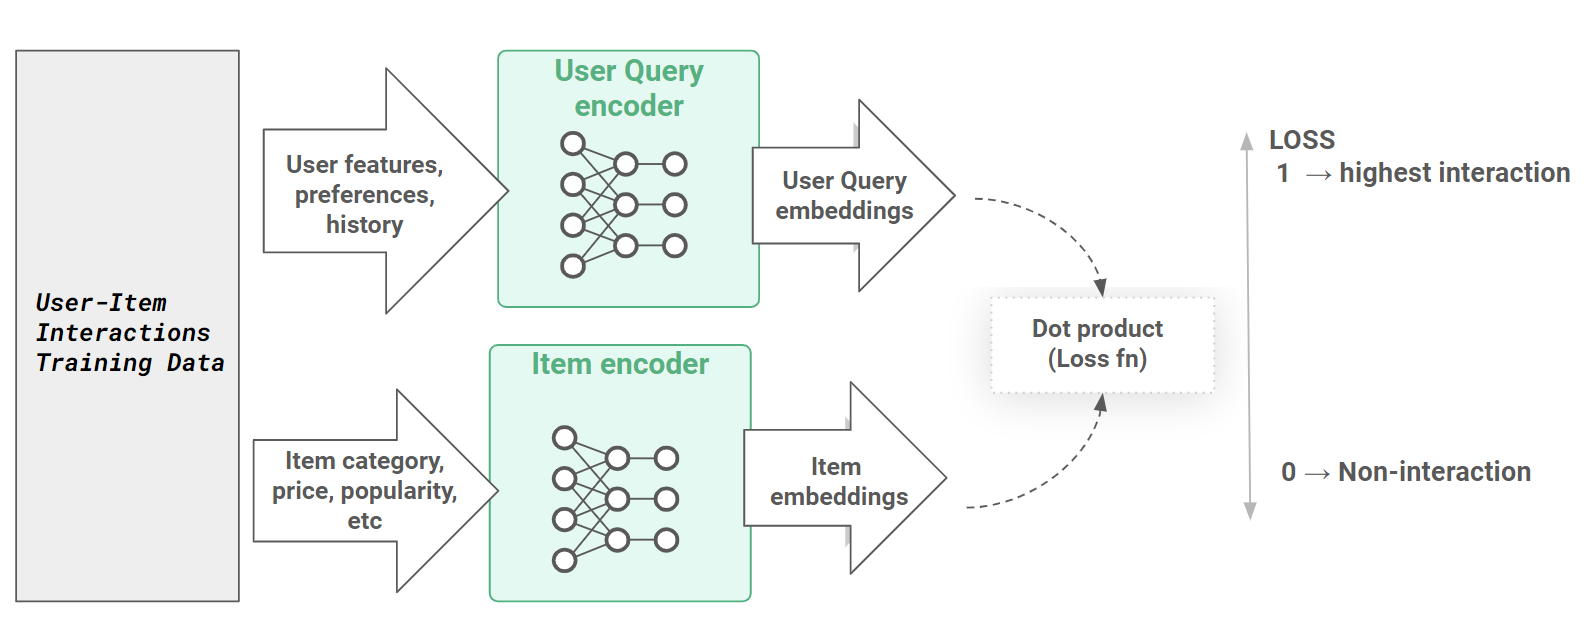

## Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder

author_encoder = LabelEncoder()
hotel_encoder = LabelEncoder()

author_encodings = author_encoder.fit_transform(ratings['authorId'])
hotel_encodings = hotel_encoder.fit_transform(ratings['hotelId'])

ratings['author_id_encoded'] = author_encodings
ratings['hotel_id_encoded'] = hotel_encodings

In [ ]:
print(ratings.head())

              authorId                                            hotelId  \
4029184          Dub26  Hotel_Review-g294197-d1626230-Reviews-Backpack...   
21481395    MathewM955  Hotel_Review-g186492-d614251-Reviews-Inishowen...   
3068631     BRANDIC869  Hotel_Review-g56208-d99225-Reviews-Hotel_Ava-L...   
21139951  andybG2108CP  Hotel_Review-g187801-d617462-Reviews-Ca_Fosca_...   
43776212        Wahaay  Hotel_Review-g34438-d87084-Reviews-Miami_Inter...   

          rating  author_id_encoded  hotel_id_encoded  
4029184      4.0             217548             90289  
21481395     1.0             358013             32770  
3068631      4.0             150695            176685  
21139951     5.0             543372             47219  
43776212     4.0             511230            138157  


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# Extract features and labels for training
train_author_ids = train['author_id_encoded'].values
train_hotel_ids = train['hotel_id_encoded'].values
train_ratings = train['rating'].values

test_author_ids = test['author_id_encoded'].values
test_hotel_ids = test['hotel_id_encoded'].values
test_ratings = test['rating'].values

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten

## User Tower

In [ ]:
embedding_dim = 50
author_input_placeholder = Input(shape=(1,), name='author_input')

#convert the author ID into a dense embedding vector of size embedding_dim
author_embedding = Embedding(input_dim=num_authors,
                           output_dim=embedding_dim,
                           name='author_embedding')(author_input_placeholder)

#remove extra dimension so the embedding becomes a simple 1D vector
author_embedding = Flatten()(author_embedding)

## Hotel Tower

In [ ]:
hotel_input_placeholder = Input(shape=(1,), name='hotel_input')

#convert the hotel ID into a dense embedding vector of size embedding_dim
hotel_embedding = Embedding(input_dim=num_hotels,
                            output_dim=embedding_dim,
                            name='hotel_embedding')(hotel_input_placeholder)

#remove extra dimension so the embedding becomes a simple 1D vector
hotel_embedding = Flatten()(hotel_embedding)

## Training

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot, Dense

In [ ]:
# Dot product of author and hotel embeddings to predict rating
dot_product = Dot(axes=1)([author_embedding, hotel_embedding])

# Output layer for predicting rating
output = Dense(1, activation='linear')(dot_product)

model = Model(inputs=[author_input_placeholder, hotel_input_placeholder], outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit([train_author_ids, train_hotel_ids], train_ratings,
                    epochs=5,
                    batch_size=64,
                    validation_data=([test_author_ids, test_hotel_ids], test_ratings))

Epoch 1/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 197s 16ms/step - loss: 3.4800 - val_loss: 1.2561
Epoch 2/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 197s 16ms/step - loss: 0.7478 - val_loss: 1.3631
Epoch 3/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 197s 16ms/step - loss: 0.3505 - val_loss: 1.4031
Epoch 4/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 197s 16ms/step - loss: 0.3244 - val_loss: 1.4050
Epoch 5/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 196s 16ms/step - loss: 0.1761 - val_loss: 1.3552


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ author_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ author_embedding    │ (None, 1, 50)     │ 45,543,100 │ author_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_embedding     │ (None, 1, 50)     │ 10,579,300 │ hotel_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ author_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ hotel_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ dot[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 168,367,208 (642.27 MB)

 Trainable params: 56,122,402 (214.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 112,244,806 (428.18 MB)

## Evaluation

In [ ]:
# Evaluate on the test set
mse = model.evaluate([test_author_ids, test_hotel_ids], test_ratings)
print(f"RMSE: {mse**(1/2)}")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 1.3552
RMSE: 1.1641364362137117


In [ ]:
test_predictions = model.predict([test_author_ids, test_hotel_ids])

# Add the original author IDs, hotel IDs, actual ratings, and predicted ratings to a DataFrame
test_results = pd.DataFrame({
    'original_author_id': author_encoder.inverse_transform(test_author_ids),  # Convert encoded author IDs back to original
    'original_hotel_id': hotel_encoder.inverse_transform(test_hotel_ids),  # Convert encoded hotel IDs back to original
    'actual_rating': test_ratings,
    'predicted_rating': test_predictions.flatten()  # Flatten to a 1D array
})

test_results.sample(10)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


,original_author_id,original_hotel_id,actual_rating,predicted_rating
128413,robt198,Hotel_Review-g1182465-d1069917-Reviews-Kirikay...,2.0,3.881638
132161,shazzafyfe11,Hotel_Review-g316000-d1206365-Reviews-Conifers...,5.0,4.049783
90208,tikihoneymoon,Hotel_Review-g60982-d86978-Reviews-Aston_Waiki...,5.0,3.800580
161474,Sjeshaw,Hotel_Review-g297701-d530530-Reviews-The_Payog...,1.0,3.962501
34909,NS228,Hotel_Review-g297476-d595251-Reviews-Casa_El_C...,5.0,3.869733
175672,jeneric69,Hotel_Review-g186311-d635185-Reviews-The_Victo...,4.0,3.837755
89523,ronniesv,Hotel_Review-g60786-d1396627-Reviews-Best_West...,2.0,3.727569
38134,CamilleCPT,Hotel_Review-g312667-d304608-Reviews-Best_Litt...,5.0,3.893275
143481,RubyWax,Hotel_Review-g675099-d3194826-Reviews-Hotel_Ca...,3.0,3.876232
85968,Rheinfarn69,Hotel_Review-g2613169-d1144577-Reviews-Hotel_G...,4.0,3.835887
